In [1]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
from sklearn.linear_model import LinearRegression  # For linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics
from sklearn.model_selection import train_test_split  # For splitting data into training and test sets
import lightgbm as lgb  # For LightGBM model
import xgboost as xgb  # For XGBoost model

In [2]:
# Load the COVID-19 dataset for India
df = pd.read_csv("covid_19_india.csv")

# Convert the 'Date' column to datetime format for better handling of time series data
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Group the data by 'Date' and sum the 'Confirmed', 'Cured', and 'Deaths' columns
# This aggregates the data to ensure that each date has a single entry
df = df.groupby('Date')[['Confirmed', 'Cured', 'Deaths']].sum().reset_index()

# Calculate daily new confirmed cases by taking the difference between consecutive days
df['New_Cases'] = df['Confirmed'].diff().fillna(0)

# Replace negative differences with zero to avoid counting negative new cases
df['New_Cases'] = df['New_Cases'].apply(lambda x: x if x > 0 else 0)

# Create lag features to provide the model with historical data
# Lag_1: New cases from the previous day
df['Lag_1'] = df['New_Cases'].shift(1)
# Lag_7: New cases from one week ago
df['Lag_7'] = df['New_Cases'].shift(7)
# Lag_14: New cases from two weeks ago
df['Lag_14'] = df['New_Cases'].shift(14)

# Drop rows with NaN values that arise from the lagging process
df = df.dropna()


C:\Users\Sumi\AppData\Local\Temp\ipykernel_5116\3381249123.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [3]:
# Define features (X) and target variable (y)
X = df[['Lag_1', 'Lag_7', 'Lag_14']]  # Features: lagged new cases
y = df['New_Cases']  # Target: new cases

# Store the date information for later use
dates = df['Date']

In [4]:
# Split the data into training and testing sets
# 20% of the data will be used for testing, and the order of the data will be preserved (no shuffling)
X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, dates, test_size=0.2, shuffle=False
)


In [5]:
# === 1. Linear Regression ===
# Initialize and fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
# Predict new cases using the Linear Regression model
y_pred_lr = lr_model.predict(X_test)

In [6]:
# === 2. LightGBM ===
# Initialize and fit the LightGBM model
lgb_model = lgb.LGBMRegressor()
lgb_model.fit(X_train, y_train)
# Predict new cases using the LightGBM model
y_pred_lgb = lgb_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 412
[LightGBM] [Info] Number of data points in the train set: 436, number of used features: 3
[LightGBM] [Info] Start training from score 37302.045872
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [7]:
# === 3. XGBoost ===
# Initialize and fit the XGBoost model
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)
# Predict new cases using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

In [8]:
# === Evaluation ===
# Define a function to evaluate the model's performance using various metrics
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)  # Mean Absolute Error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Root Mean Squared Error
    r2 = r2_score(y_true, y_pred)  # R-squared score
    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    }
# Evaluate all models and store the results
results = [
    evaluate_model(y_test, y_pred_lr, "Linear Regression"),
    evaluate_model(y_test, y_pred_lgb, "LightGBM"),
    evaluate_model(y_test, y_pred_xgb, "XGBoost"),
]
# Convert results into a DataFrame for better visualization
results_df = pd.DataFrame(results)
print("\n📊 Model Comparison:\n", results_df)



📊 Model Comparison:
                Model       MAE      RMSE  R2 Score
0  Linear Regression   9571.78  15091.02    0.9868
1           LightGBM  46835.19  70520.36    0.7111
2            XGBoost  23231.13  36722.87    0.9217


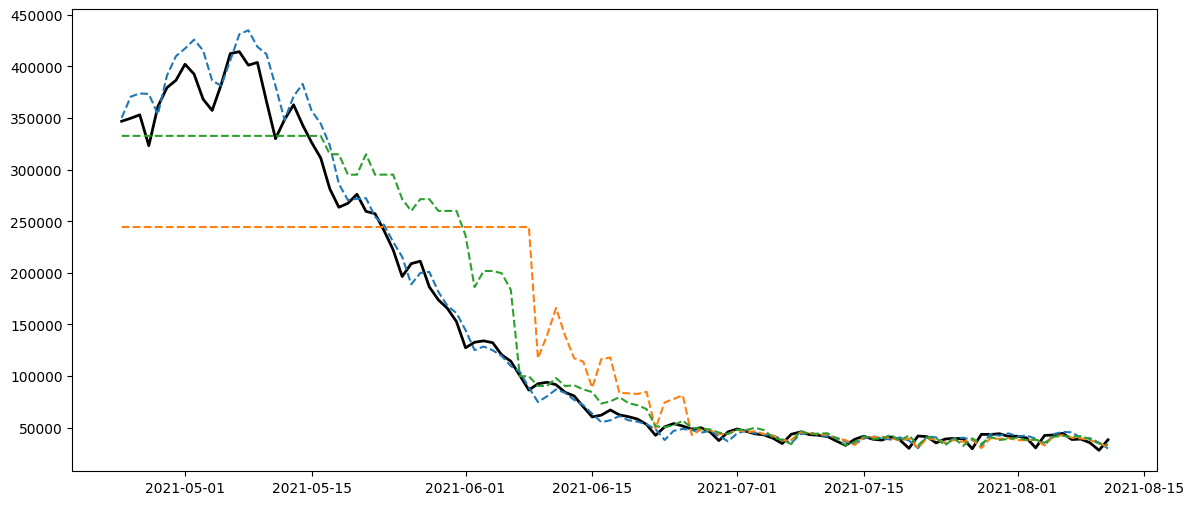

In [9]:
# === Plot Actual vs Predicted ===
# Create a plot to compare actual new cases with predicted values
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test.values, label="Actual Cases", color='black', linewidth=2)  # Actual cases
plt.plot(dates_test, y_pred_lr, label="Linear Regression", linestyle='--')  # Predicted cases by Linear Regression
plt.plot(dates_test, y_pred_lgb, label="LightGBM", linestyle='--')  # Predicted cases by LightGBM
plt.plot(dates_test, y_pred_xgb, label="XGBoost", linestyle='--')  # Predicted cases by XGBoost


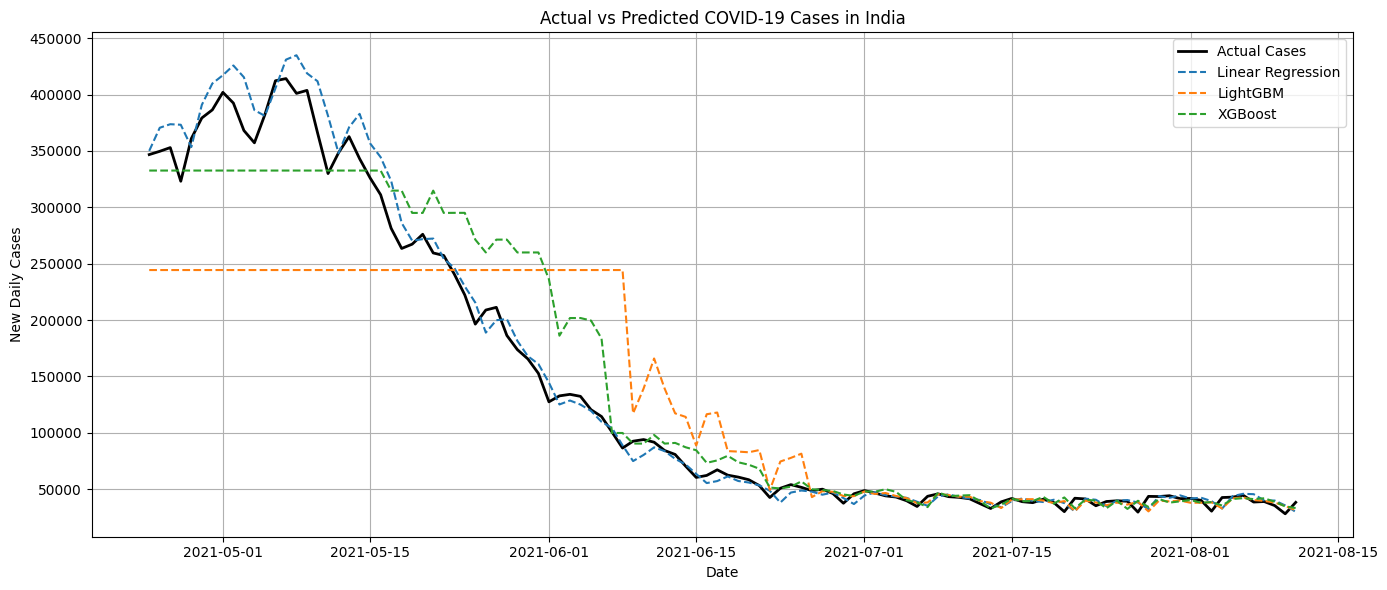

In [11]:
# === Plot Actual vs Predicted ===
# Create a plot to compare actual new cases with predicted values
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test.values, label="Actual Cases", color='black', linewidth=2)  # Actual cases
plt.plot(dates_test, y_pred_lr, label="Linear Regression", linestyle='--')  # Predicted cases by Linear Regression
plt.plot(dates_test, y_pred_lgb, label="LightGBM", linestyle='--')  # Predicted cases by LightGBM
plt.plot(dates_test, y_pred_xgb, label="XGBoost", linestyle='--')  # Predicted cases by XGBoost
# Labeling the axes and adding title and legend
plt.xlabel("Date")
plt.ylabel("New Daily Cases")
plt.title("Actual vs Predicted COVID-19 Cases in India")
plt.legend()  # Show legend
plt.tight_layout()  # Adjust layout
plt.grid(True)  # Add grid for better readability
plt.show()  # Display the plot